# Predicting answer reading times

One regression per answer (A / B / C / D): how long the participant spent reading
that answer, predicted from how they read the **paragraph** plus the answer's own
text size. Deliberately no answer-area eye-tracking predictors.

Two predictor sets are compared throughout:

| set | n | built by |
| --- | --- | --- |
| ours (span metrics) | 49 | `answer_RTs/features.py` + `answer_RTs/answer_text_features.py` |
| external (EyeBench) | ~520 | the lab's extraction, `src/derived/external/EyeBench/` |

All of the code lives in `src/predictive_modeling/answer_RTs/`
(`features.py`, `answer_text_features.py`, `model_data.py`, `models/linreg_model.py`,
`run.py`). Split out of `text_associations.ipynb`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Trial-level paragraph reading features (lab's external extraction)

Runs the feature extraction taken from the lab's EyeBench / OneStop pipeline
(vendored in `src/external/EyeBench/`, constants in
`src/external/EyeBench/configs/constants.py`) on our paragraph reports, via the
adapter `src/external/EyeBench/paragraph_trial_features.py` — which also reproduces
their `OneStopProcessor` preprocessing step-for-step, since our reports are raw
where theirs are already processed. The cell below only sets the switches; the
driver that turns them into a run is `src/derived/external/EyeBench/runner.py`.

One row per (`participant_id`, `TRIAL_INDEX`) trial, **1275 columns** with `RECONSTRUCT`
on (1240 without), each tagged by model family in the two
`*_trial_level_feature_keys.csv` files written alongside:

| family | n | what |
| --- | --- | --- |
| `RF` | 546 | every column of `numerical_ia_trial_columns` / `numerical_fixation_trial_columns` × 7 aggregations (mean/std/median/skew/kurtosis/max/min), prefixed `ia_feature_` / `fix_feature_` |
| `BEYELSTM` | 676 | gaze entropy (`fixation_feature_SGE` / `GTE`), fixation & word counts, and the 16 `gsf_features` averaged per word category → `<category>_<value>_<feature>` (`is_content_word`, `ptb_pos` = reduced POS `0.0`–`4.0` = FUNC/NOUN/VERB/ADJ/UNKNOWN, `entity_type`, `universal_pos`) |
| `SVM` | 9 | `skip_rate`, `num_of_fixations`, `mean_TFD`, `NEXT_SAC_*_mean/max` |
| `LOGISTIC` | 9 | `first_pass_skip_rate`, `mean_FFD/GD/TFD`, `mean_go_past_time`, `CURRENT_FIX_DURATION_mean`, `forward_saccade_length_mean`, `regression_rate` |
| `READING_SPEED` | 1 | `reading_speed` — words per **ms** (`PARAGRAPH_RT` is in ms) |

Practice and repeated-reading trials are dropped (as in `split_hunters_and_gatherers`);
`question_preview` (hunter = 1 / gatherer = 0) is attached for splitting later.

Three things to know before modelling:

- **~145 columns are constant zero.** Degenerate aggregations (`min` of count columns,
  spread of trial-constant columns like `PARAGRAPH_RT`), plus **all 80 `ptb_pos_*`
  columns** — in the source pipeline `ptb_pos` is mapped to numbers by
  `add_missing_features` and then mapped again per trial, yielding all-NaN and an
  empty grouping. `FIX_PTB_POS = True` gives them real values (function words 311 ms
  mean dwell vs. nouns 448).
- **23 of the `RECONSTRUCT` columns are exact duplicates** of features that already
  exist under our own column names (`ia_feature_*_landing_position` ==
  `ia_feature_*_IA_FIRST_RUN_LANDING_POSITION`, and likewise for
  `IA_FIRST_FIX_DURATION` / `IA_TOTAL_FIXATION_DURATION`). The 12 genuinely new ones
  are per-word saccade duration and peak velocity, aggregated from the fixation report.
- Words with no named entity are dropped from the `entity_type` grouping rather than
  forming a `NONE` category, as in the source.

The full build reads two multi-GB reports and takes ~1.5 h, so the result is cached at
`PARAGRAPH_TRIAL_FEATURES_PATH` and only `REBUILD = True` ever overwrites it.
Use `QUICK_TEST` for a fast smoke run first (it writes neither the cache nor the
real key files).

In [2]:
from src.derived.external.EyeBench.runner import (
    get_paragraph_trial_features,
    feature_key_summary,
)

REBUILD = False   # True -> re-run the extraction and overwrite the cached CSV
QUICK_TEST = 0    # >0 -> only that many participants (a fast smoke run, not saved)
WITH_FIXATIONS = True  # False -> IA-only features (much faster, drops the fix_/gsf ones)

# False reproduces the source pipeline exactly, where the 80 ptb_pos_* columns come
# out all-zero because ptb_pos is mapped to numbers twice. True gives them real
# values. Nothing else differs between the two.
FIX_PTB_POS = True

# Fill IA columns their feature list wants but our report names differently or
# lacks (see reconstruct_source_columns): +35 columns, of which 23 duplicate
# existing ones exactly and 12 are new (per-word saccade duration / velocity).
RECONSTRUCT = True

trial_features = get_paragraph_trial_features(
    rebuild=REBUILD,
    quick_test=QUICK_TEST,
    include_fixation_features=WITH_FIXATIONS,
    fix_ptb_pos_double_mapping=FIX_PTB_POS,
    reconstruct_missing_columns=RECONSTRUCT,
)

# What each feature belongs to (written by the extraction: RF / BEYELSTM / SVM /
# LOGISTIC / READING_SPEED).
display(feature_key_summary())

trial_features.head()

trial-level paragraph features: (19438, 528)


source    feature_type 
fixation  BEYELSTM         596
          LOGISTIC           3
          RF               322
          SVM                6
ia        LOGISTIC           6
          READING_SPEED      1
          RF               259
          SVM                3
Name: n_features, dtype: int64

,participant_id,TRIAL_INDEX,fix_feature_mean_CURRENT_FIX_DURATION,fix_feature_std_CURRENT_FIX_DURATION,fix_feature_median_CURRENT_FIX_DURATION,fix_feature_skew_CURRENT_FIX_DURATION,fix_feature_kurtosis_CURRENT_FIX_DURATION,fix_feature_max_CURRENT_FIX_DURATION,fix_feature_min_CURRENT_FIX_DURATION,fix_feature_mean_CURRENT_FIX_PUPIL,...,ia_feature_min_IA_MIN_FIX_PUPIL_SIZE,skip_rate,num_of_fixations,mean_TFD,first_pass_skip_rate,mean_FFD,mean_GD,mean_go_past_time,reading_speed,question_preview
0,l10_202,3,180.557252,70.070102,175.0,1.294693,4.544828,501.0,25.0,928.839695,...,799.0,0.265060,131,284.975904,0.602410,187.852459,241.377049,274.081967,0.002689,0
1,l10_202,4,179.840659,63.160461,170.0,1.341336,5.359139,536.0,36.0,913.104396,...,796.0,0.248366,182,213.928105,0.411765,183.234783,215.486957,231.556522,0.003570,0
2,l10_202,6,164.600000,55.612567,162.0,1.106015,2.857553,395.0,48.0,871.341176,...,791.0,0.236842,85,184.092105,0.315789,165.672414,191.775862,209.465517,0.004186,0
3,l10_202,7,183.842520,62.567938,180.0,0.330660,0.227690,364.0,29.0,843.724409,...,703.0,0.254717,127,220.264151,0.556604,190.316456,220.658228,245.924051,0.003466,0
4,l10_202,8,190.385714,94.941379,174.0,2.591273,10.070930,722.0,27.0,857.500000,...,723.0,0.168831,348,430.629870,0.487013,186.085938,244.203125,266.867188,0.001777,0


In [3]:
trial_features

,participant_id,TRIAL_INDEX,fix_feature_mean_CURRENT_FIX_DURATION,fix_feature_std_CURRENT_FIX_DURATION,fix_feature_median_CURRENT_FIX_DURATION,fix_feature_skew_CURRENT_FIX_DURATION,fix_feature_kurtosis_CURRENT_FIX_DURATION,fix_feature_max_CURRENT_FIX_DURATION,fix_feature_min_CURRENT_FIX_DURATION,fix_feature_mean_CURRENT_FIX_PUPIL,...,ia_feature_min_IA_MIN_FIX_PUPIL_SIZE,skip_rate,num_of_fixations,mean_TFD,first_pass_skip_rate,mean_FFD,mean_GD,mean_go_past_time,reading_speed,question_preview
0,l10_202,3,180.557252,70.070102,175.0,1.294693,4.544828,501.0,25.0,928.839695,...,799.0,0.265060,131,284.975904,0.602410,187.852459,241.377049,274.081967,0.002689,0
1,l10_202,4,179.840659,63.160461,170.0,1.341336,5.359139,536.0,36.0,913.104396,...,796.0,0.248366,182,213.928105,0.411765,183.234783,215.486957,231.556522,0.003570,0
2,l10_202,6,164.600000,55.612567,162.0,1.106015,2.857553,395.0,48.0,871.341176,...,791.0,0.236842,85,184.092105,0.315789,165.672414,191.775862,209.465517,0.004186,0
3,l10_202,7,183.842520,62.567938,180.0,0.330660,0.227690,364.0,29.0,843.724409,...,703.0,0.254717,127,220.264151,0.556604,190.316456,220.658228,245.924051,0.003466,0
4,l10_202,8,190.385714,94.941379,174.0,2.591273,10.070930,722.0,27.0,857.500000,...,723.0,0.168831,348,430.629870,0.487013,186.085938,244.203125,266.867188,0.001777,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19433,l9_536,68,211.190476,64.009686,212.0,0.305566,-0.230834,406.0,93.0,835.133333,...,714.0,0.392857,105,197.991071,0.500000,215.441176,238.794118,268.867647,0.004449,1
19434,l9_536,69,200.174603,66.989348,200.0,0.404514,0.610639,408.0,28.0,858.111111,...,712.0,0.474227,63,130.010309,0.546392,199.941176,220.235294,234.019608,0.006676,1
19435,l9_536,70,201.826531,68.144209,189.0,0.655140,0.719233,424.0,72.0,832.591837,...,664.0,0.387755,98,201.826531,0.489796,215.500000,226.616667,237.150000,0.004304,1
19436,l9_536,71,219.938272,81.342948,222.0,0.695902,0.330007,484.0,78.0,871.382716,...,702.0,0.386364,81,202.443182,0.522727,229.018519,238.148148,259.481481,0.004324,1


## Predict answer reading times from paragraph features

One regression per answer (A/B/C/D). Predictors are paragraph-only: per-span area
metrics, per-span RT/TFD (pure + normalized), and the hunter/gatherer preview
flag — no answer-area eye-tracking features. Pick `FEATURE_COLS` to control what
goes in.

On top of `FEATURE_COLS`, `make_answer_rt_dataset` appends six **text-size**
predictors aligned to the target answer — `answer_len_words`, `answer_len_chars`,
`answer_len_words_rel`, `answers_total_len_words`, `answers_std_len_words`,
`question_len_words` (from `answer_text_features.py`, cached at
`ANSWER_TEXT_FEATURES_PATH`). They describe the *stimulus*, not how the answer was
read, so the paragraph-only rule still holds; pass `include_answer_text=False` to
drop them. They dominate: on `RT_normalized` answer A they take held-out R² from
0.02 to 0.25, and the six alone beat the 43 eye-tracking features.

Read that gain with one caveat — `RT_normalized_*` is RT divided by the answer's
word count, and `answer_len_words` reproduces that denominator on 97–99.7% of
trials, so part of what the model recovers is the `1/length` shape. Against
`RT_pure_*` the same features give 0.056 → 0.148, which is the cleaner comparison.
The honest framing is *incremental over a text-length baseline*, which the
`include_answer_text=False` runs give you.

The cell after this section re-runs the same regression on the external
trial-level features extracted above, for comparison.

In [3]:
from src.predictive_modeling.answer_RTs.model_data import (
    build_answer_rt_model_df,
    make_answer_rt_dataset,
    get_paragraph_feature_cols,
    get_span_area_feature_cols,
    get_span_rt_tfd_feature_cols,
    get_preview_feature_cols,
)
from src.predictive_modeling.answer_RTs.run import run_answer_rt_regression

# Trial-level frame: paragraph predictors + answer-RT targets (built once).
answer_rt_model_df = build_answer_rt_model_df()
print("model df:", answer_rt_model_df.shape)


def run_label(out, answers=("A", "B", "C", "D")):
    """What a figure is based on: '<feature set> · <target> · <n> features'.

    `feature_set` is whatever label was passed to `run_answer_rt_regression`;
    unlabelled runs still get the target and the predictor count.
    """
    m = out["results"][answers[0]]["metrics"]
    parts = [out["feature_set"]] if out.get("feature_set") else []
    parts.append(m["target"].rsplit("_answer_", 1)[0])
    parts.append(f"{m['n_features']} features")
    return "  ·  ".join(parts)


def plot_true_pred(out, answers=("A", "B", "C", "D")):
    """2x2 held-out true-vs-predicted scatter, coloured by reading regime."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, ans in zip(axes.ravel(), answers):
        res = out["results"][ans]
        p, m = res["predictions"], res["metrics"]
        if "question_preview" in p.columns:
            for val, lab, c in [(1, "hunter", "tab:orange"), (0, "gatherer", "tab:blue")]:
                s = p[p["question_preview"] == val]
                ax.scatter(s["y_true"], s["y_pred"], s=6, alpha=0.3, color=c, label=lab)
            ax.legend(fontsize=8)
        else:
            ax.scatter(p["y_true"], p["y_pred"], s=6, alpha=0.3)
        lo = float(min(p["y_true"].min(), p["y_pred"].min()))
        hi = float(max(p["y_true"].max(), p["y_pred"].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"answer {ans}:  R²={m['r2']:.3f}   RMSE={m['rmse']:.0f}")
        ax.set_xlabel("true RT")
        ax.set_ylabel("predicted RT")
    fig.suptitle(f"True vs predicted — {run_label(out, answers)}", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_coefs(out, answers=("A", "B", "C", "D"), top_k=12):
    """2x2 top-|coef| feature weights per answer.

    What the bars are depends on the model: signed standardized coefficients for
    the linear kinds (features are z-scored), unsigned permutation importance for
    the GBM. The run reports which as `coef_kind`, and it goes in the title.
    """
    coef_kind = out["results"][answers[0]].get("coef_kind", "standardized coefficient")
    if out["results"][answers[0]]["coef_summary"].empty:
        # e.g. a GBM fit with compute_importance=False -- nothing was measured.
        print(f"no {coef_kind} available for this run")
        return
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, ans in zip(axes.ravel(), answers):
        cs = out["results"][ans]["coef_summary"].head(top_k).iloc[::-1]
        colors = ["tab:red" if v < 0 else "tab:green" for v in cs["coef"]]
        ax.barh(cs["feature"], cs["coef"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(f"answer {ans} — top {top_k} |coef|")
        ax.tick_params(labelsize=7)
    fig.suptitle(f"Top {top_k} by {coef_kind} — {run_label(out, answers)}", y=1.01)
    plt.tight_layout()
    plt.show()


# --- choose which features to run -------------------------------------------
FEATURE_COLS = get_paragraph_feature_cols(answer_rt_model_df)   # everything (default)
# FEATURE_COLS = get_span_rt_tfd_feature_cols(answer_rt_model_df) + get_preview_feature_cols(answer_rt_model_df)
# FEATURE_COLS = get_span_area_feature_cols(answer_rt_model_df)

# --- answer/question text sizes: one switch, honoured by every run below -----
# True  -> the six text-size predictors are in (three trial-level ones already
#          sit inside FEATURE_COLS, three more are target-aligned per answer).
# False -> all six are stripped, including the ones already in FEATURE_COLS,
#          leaving a pure eye-tracking model. That is the baseline the text
#          features should be reported as incremental over -- on our set it is
#          R2 = 0.025, against 0.246 (ridge) and 0.333 (GBM) with them.
INCLUDE_ANSWER_TEXT = True

# The count that actually gets fitted depends on the switch, so ask for it.
n_fitted = len(
    make_answer_rt_dataset(
        answer_rt_model_df,
        "A",
        feature_cols=FEATURE_COLS,
        include_answer_text=INCLUDE_ANSWER_TEXT,
    ).feature_cols
)
print(
    f"n features chosen: {len(FEATURE_COLS)} -> {n_fitted} fitted "
    f"(INCLUDE_ANSWER_TEXT={INCLUDE_ANSWER_TEXT})"
)

model df: (19436, 66)
n features chosen: 46 -> 49 fitted (INCLUDE_ANSWER_TEXT=True)


In [ ]:
out_answer_rt = run_answer_rt_regression(
    model_df=answer_rt_model_df,
    feature_cols=FEATURE_COLS,
    feature_set="ours (span metrics)",   # labels the figures below
    include_answer_text=INCLUDE_ANSWER_TEXT,
    rt_metric="RT_normalized",   # target: RT_normalized_answer_{A..D} ("RT_pure" also available)
    model_kind="ridge",          # alpha defaults to the pre-tuned value for this set's width
    # alpha=1.0,                 # ...or pin it; "ridge_cv" re-runs the search; "linear" for none
    test_size=0.2,
    random_state=42,
)

# per-answer held-out metrics
display(out_answer_rt["metrics"].round(3))

# coefficients and true/predicted
plot_coefs(out_answer_rt)
plot_true_pred(out_answer_rt)

### The same regression on the external trial-level features

Identical setup — one ridge per answer, participant-grouped split, `RT_normalized`
target — with the predictors swapped for the EyeBench trial-level features
extracted above. Still paragraph-only: the extraction runs on the paragraph
reports, so no answer-area information gets in. Constant columns (the degenerate
aggregations noted above) are dropped, leaving ~516 predictors against the 49 of
our own set. The target-aligned text features are appended to both sets, so the
two differ only in their eye-tracking predictors.

external model df: (19436, 549)
n features chosen: 516
answer A: R2=0.234 RMSE=312.202 (baseline 356.835) MAE=173.548  [alpha=100, n_feat=522, n_train=15549, n_test=3887]
answer B: R2=0.128 RMSE=249.305 (baseline 267.118) MAE=144.289  [alpha=100, n_feat=522, n_train=15549, n_test=3887]
answer C: R2=0.149 RMSE=212.772 (baseline 230.700) MAE=120.946  [alpha=100, n_feat=522, n_train=15549, n_test=3887]
answer D: R2=0.134 RMSE=198.493 (baseline 213.318) MAE=113.431  [alpha=100, n_feat=522, n_train=15549, n_test=3887]


,feature_set,answer,target,model_kind,alpha,n_iter,n_train,n_test,n_features,r2,rmse,mae,baseline_rmse
0,external (EyeBench),A,RT_normalized_answer_A,ridge,100.0,None,15549,3887,522,0.234,312.202,173.548,356.835
1,external (EyeBench),B,RT_normalized_answer_B,ridge,100.0,None,15549,3887,522,0.128,249.305,144.289,267.118
2,external (EyeBench),C,RT_normalized_answer_C,ridge,100.0,None,15549,3887,522,0.149,212.772,120.946,230.700
3,external (EyeBench),D,RT_normalized_answer_D,ridge,100.0,None,15549,3887,522,0.134,198.493,113.431,213.318


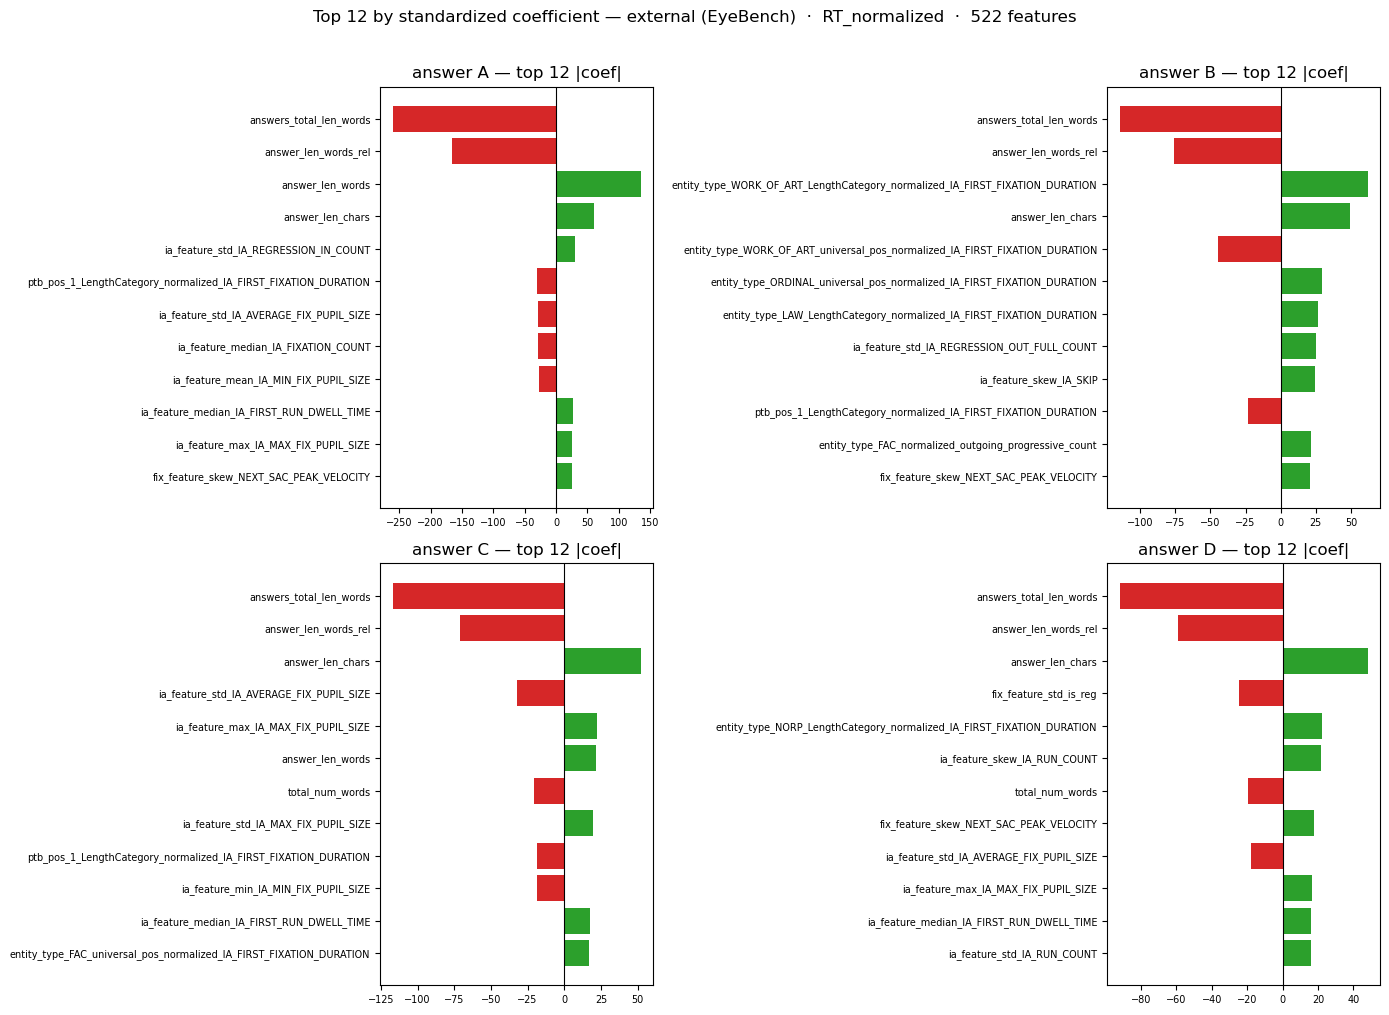

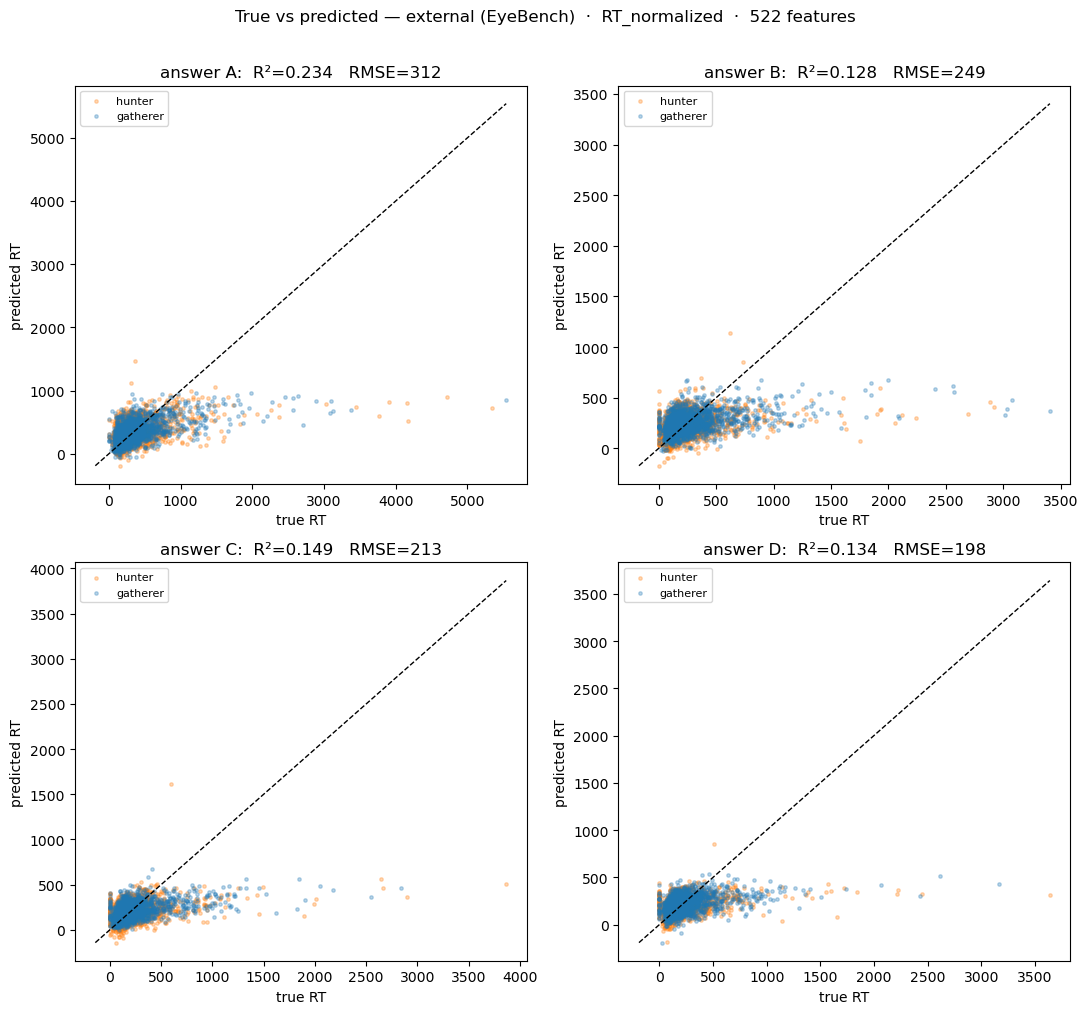

In [4]:
from src.predictive_modeling.answer_RTs.model_data import (
    build_external_answer_rt_model_df,
    get_external_feature_cols,
)

# Same targets and same key as `answer_rt_model_df`, only the predictors differ.
external_rt_model_df = build_external_answer_rt_model_df(trial_features=trial_features)
EXTERNAL_FEATURE_COLS = get_external_feature_cols(external_rt_model_df)
print("external model df:", external_rt_model_df.shape)
print("n features chosen:", len(EXTERNAL_FEATURE_COLS))

out_answer_rt_external = run_answer_rt_regression(
    model_df=external_rt_model_df,
    feature_cols=EXTERNAL_FEATURE_COLS,
    feature_set="external (EyeBench)",
    include_answer_text=INCLUDE_ANSWER_TEXT,
    rt_metric="RT_normalized",   # target: RT_normalized_answer_{A..D} ("RT_pure" also available)
    model_kind="ridge",          # pre-tuned to 100 here: 516 predictors need far more than alpha=1
    test_size=0.2,
    random_state=42,
)

# per-answer held-out metrics
display(out_answer_rt_external["metrics"].round(3))

# coefficients and true/predicted
plot_coefs(out_answer_rt_external)
plot_true_pred(out_answer_rt_external)


# Named once here; the regularization and target cells below both use this.
FEATURE_SETS = {
    "ours (span metrics)": (answer_rt_model_df, FEATURE_COLS),
    "external (EyeBench)": (external_rt_model_df, EXTERNAL_FEATURE_COLS),
}


### Choosing the ridge penalty

The penalty is **not** searched on an ordinary run. `alpha=None` (the default)
resolves to the value the search already settled on for a predictor set of that
width — `tuned_alpha` in `models/linreg_model.py`: 10 for our ~49 columns, 100
for the ~520 external ones. Pass an explicit `alpha` to override it. The value
actually used comes back in the `alpha` column of the metrics frame either way.

`model_kind="ridge_cv"` re-runs the search instead, by inner cross-validation on
the training split folded **by participant** to match the outer split — a plain
KFold would put the same reader on both sides and tune the penalty on leakage.
Worth doing when the predictor set or target has changed enough that the recorded
value should not be trusted; `alphas=[...]` changes its candidate grid, and
`lasso_cv` / `elasticnet_cv` are also available.

Skipping the search costs almost nothing and saves real time: on our set the
fixed penalty gives mean held-out R² 0.1720 against the search's 0.1723 (0.4 s
vs 2.5 s), and on the external set 0.161 against 0.163 (3 s vs 22 s).

The sweep below runs the fixed grid alongside a CV pick, so a chosen penalty can
be read as either a real optimum or an arbitrary point on a plateau — that is how
the two defaults above were picked, and how to re-derive them. For our 49
predictors the metric is flat from 0.01 to 100 and only decays past 1000. For the
~520 external ones the useful range sits an order of magnitude higher, though with
the text features carrying most of the signal the gain is modest: answer B goes
0.118 at `alpha=1` to 0.130 at the CV pick. Re-run either set with
`include_answer_text=False` and the penalty matters far more — external answer B
is 0.009 at `alpha=1` against 0.045 at its CV pick of 10 000.


In [ ]:
from src.predictive_modeling.answer_RTs.run import sweep_answer_rt_alphas

alpha_sweep = pd.concat(
    [
        sweep_answer_rt_alphas(
            model_df=df_,
            feature_cols=cols_,
            feature_set=name,
            include_answer_text=INCLUDE_ANSWER_TEXT,
            rt_metric="RT_normalized",
            verbose=False,
        )
        for name, (df_, cols_) in FEATURE_SETS.items()
    ],
    ignore_index=True,
)

# Held-out R2 per answer, one row per penalty setting.
display(
    alpha_sweep.pivot_table(
        index=["feature_set", "setting"], columns="answer", values="r2", sort=False
    ).round(4)
)

### Choosing the reading-time target

Same ridge, same participant-grouped split, both feature sets — only the target
changes. Two switches in the next cell give the four variants: `RT_METRIC` picks
raw milliseconds (`RT_pure`) or per-word rate (`RT_normalized`), and `LOG_TARGET`
takes the log of it.

Raw answer RTs are skewed +3.2 to +13.8; in logs they are near-symmetric (skew
−0.15 to +0.50), so a squared-error fit stops spending its capacity on the tail.
Trials where the answer was never fixated (`RT = 0`, 0.3–2.8% depending on the
answer) are dropped rather than shifted — they are a skip, not a fast read, and
`log1p` would place them 7 log-units below every real observation.

With `LOG_TARGET = True`, R² is the share of variance in *log* RT explained and
RMSE is in log units, so neither is comparable to a raw-RT run. Compare across
the four only within a column of the sweep below.

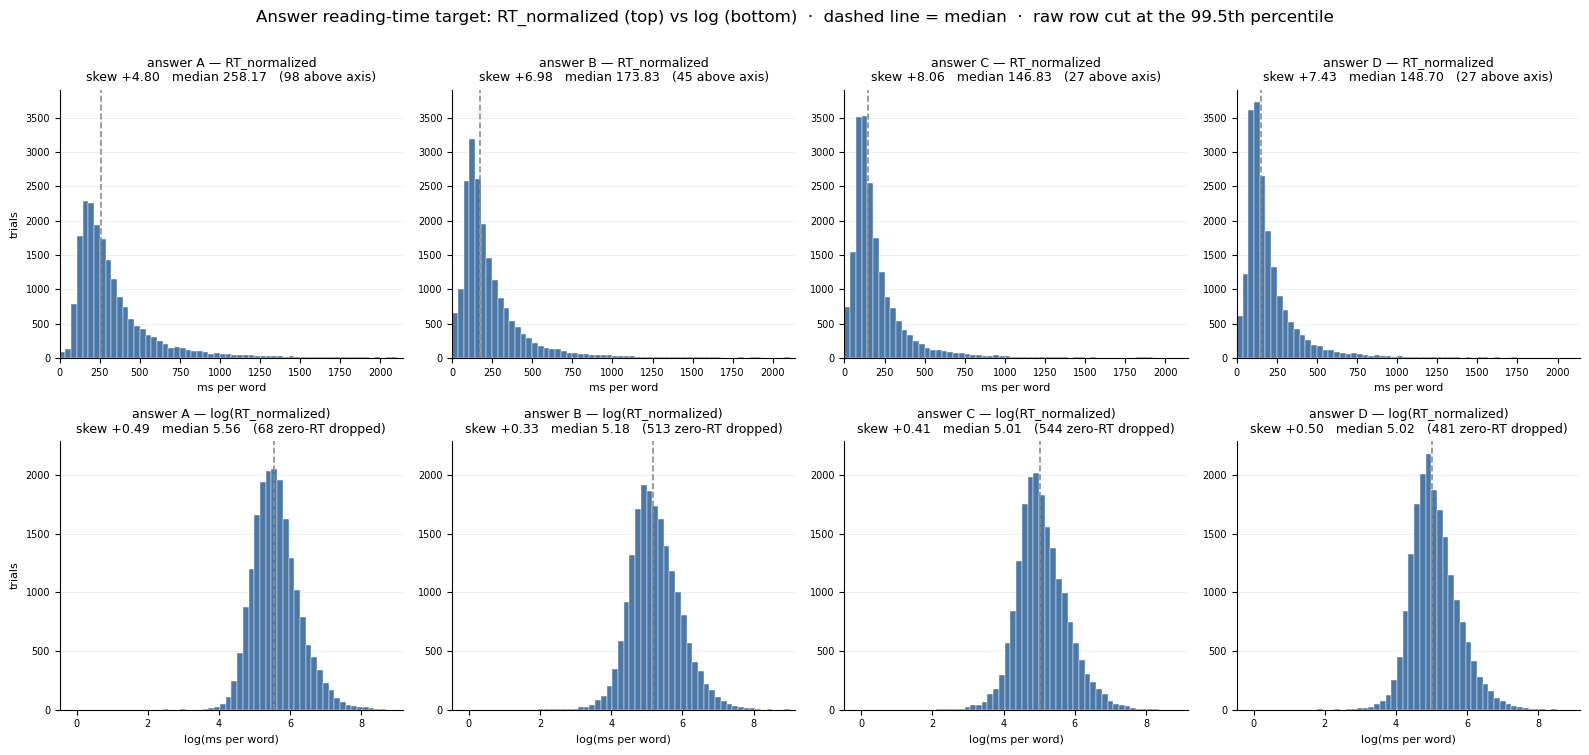

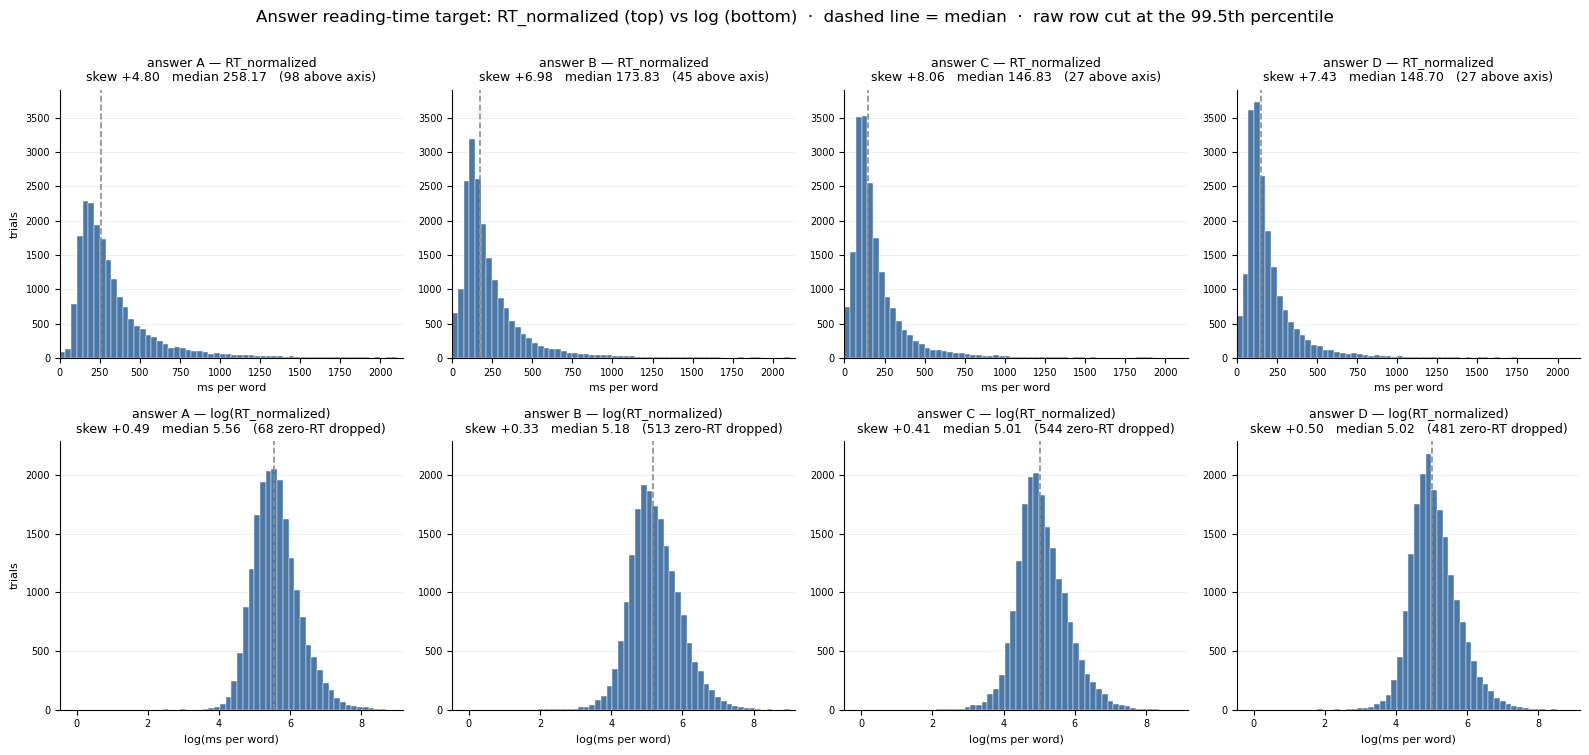

In [8]:
from src.predictive_modeling.answer_RTs.model_data import (
    ANSWER_LABELS,
    answer_rt_target_col,
)

BAR = "#4C78A8"     # one hue: every panel is the same single series
REF = "#8C8C8C"     # recessive reference line


def plot_target_distributions(
    model_df, rt_metric="RT_normalized", bins=60, raw_clip_pct=99.5
):
    """Raw vs log distribution of the answer-RT target, one column per answer.

    Top row is the target as modelled without `log_target`, bottom row is what
    `log_target=True` actually fits. Trials with RT = 0 (the answer was never
    fixated) are excluded from the log row, as `make_answer_rt_dataset` does;
    each panel reports how many that was.

    Axes are shared down each row so the four answers are comparable. The raw
    row's tail runs to ~10x its own median, which would squash every panel into
    the left edge, so it is cut at `raw_clip_pct` -- the clipped trials are
    counted in the row label, and the skew/median annotations are computed on
    the full data, not the visible part.
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))

    raw_by_answer, log_by_answer = {}, {}
    for ans in ANSWER_LABELS:
        target = answer_rt_target_col(ans, rt_metric=rt_metric)
        raw = pd.to_numeric(model_df[target], errors="coerce").dropna()
        raw_by_answer[ans] = raw
        log_by_answer[ans] = np.log(raw[raw > 0])

    raw_hi = max(np.percentile(v, raw_clip_pct) for v in raw_by_answer.values())
    log_lo = min(v.min() for v in log_by_answer.values())
    log_hi = max(v.max() for v in log_by_answer.values())

    rows = (
        (raw_by_answer, rt_metric, (0, raw_hi), "ms per word"),
        (log_by_answer, f"log({rt_metric})", (log_lo, log_hi), "log(ms per word)"),
    )

    for row, (series, name, xlim, xlabel) in enumerate(rows):
        for col, ans in enumerate(ANSWER_LABELS):
            vals = series[ans]
            ax = axes[row, col]
            ax.hist(
                vals,
                bins=np.linspace(*xlim, bins + 1),
                color=BAR,
                edgecolor="white",
                linewidth=0.3,
            )
            ax.axvline(vals.median(), color=REF, ls="--", lw=1.2)

            if row == 0:
                n_clipped = int((vals > xlim[1]).sum())
                detail = f"{n_clipped} above axis"
            else:
                n_zero = len(raw_by_answer[ans]) - len(vals)
                detail = f"{n_zero} zero-RT dropped"
            ax.set_title(
                f"answer {ans} — {name}\n"
                f"skew {vals.skew():+.2f}   median {vals.median():.2f}   ({detail})",
                fontsize=9,
            )

            ax.set_xlim(*xlim)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(axis="y", alpha=0.25, lw=0.6)
            ax.set_axisbelow(True)
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)
            if col == 0:
                ax.set_ylabel("trials", fontsize=8)

        # Same y across a row: all four answers have the same n, so differing
        # heights would read as a difference in sample size.
        top = max(ax.get_ylim()[1] for ax in axes[row])
        for ax in axes[row]:
            ax.set_ylim(0, top)

    fig.suptitle(
        f"Answer reading-time target: {rt_metric} (top) vs log (bottom)  ·  "
        f"dashed line = median  ·  raw row cut at the {raw_clip_pct}th percentile",
        y=1.00,
    )
    plt.tight_layout()
    plt.show()
    return fig


plot_target_distributions(answer_rt_model_df, rt_metric="RT_normalized")
# plot_target_distributions(answer_rt_model_df, rt_metric="RT_pure")


target: log(RT_normalized)
answer A: R2=0.299 RMSE=0.558 (baseline 0.667) MAE=0.434  [alpha=10, n_feat=49, n_train=15492, n_test=3876]
answer B: R2=0.197 RMSE=0.651 (baseline 0.727) MAE=0.513  [alpha=10, n_feat=49, n_train=15110, n_test=3813]
answer C: R2=0.223 RMSE=0.630 (baseline 0.714) MAE=0.488  [alpha=10, n_feat=49, n_train=15093, n_test=3799]
answer D: R2=0.234 RMSE=0.595 (baseline 0.680) MAE=0.461  [alpha=10, n_feat=49, n_train=15138, n_test=3817]
answer A: R2=0.295 RMSE=0.560 (baseline 0.667) MAE=0.435  [alpha=100, n_feat=522, n_train=15492, n_test=3876]
answer B: R2=0.200 RMSE=0.650 (baseline 0.727) MAE=0.513  [alpha=100, n_feat=522, n_train=15110, n_test=3813]
answer C: R2=0.234 RMSE=0.625 (baseline 0.714) MAE=0.486  [alpha=100, n_feat=522, n_train=15093, n_test=3799]
answer D: R2=0.239 RMSE=0.593 (baseline 0.680) MAE=0.456  [alpha=100, n_feat=522, n_train=15138, n_test=3817]


answer,A,B,C,D
feature_set,,,,
external (EyeBench),0.295,0.200,0.234,0.239
ours (span metrics),0.299,0.197,0.223,0.234


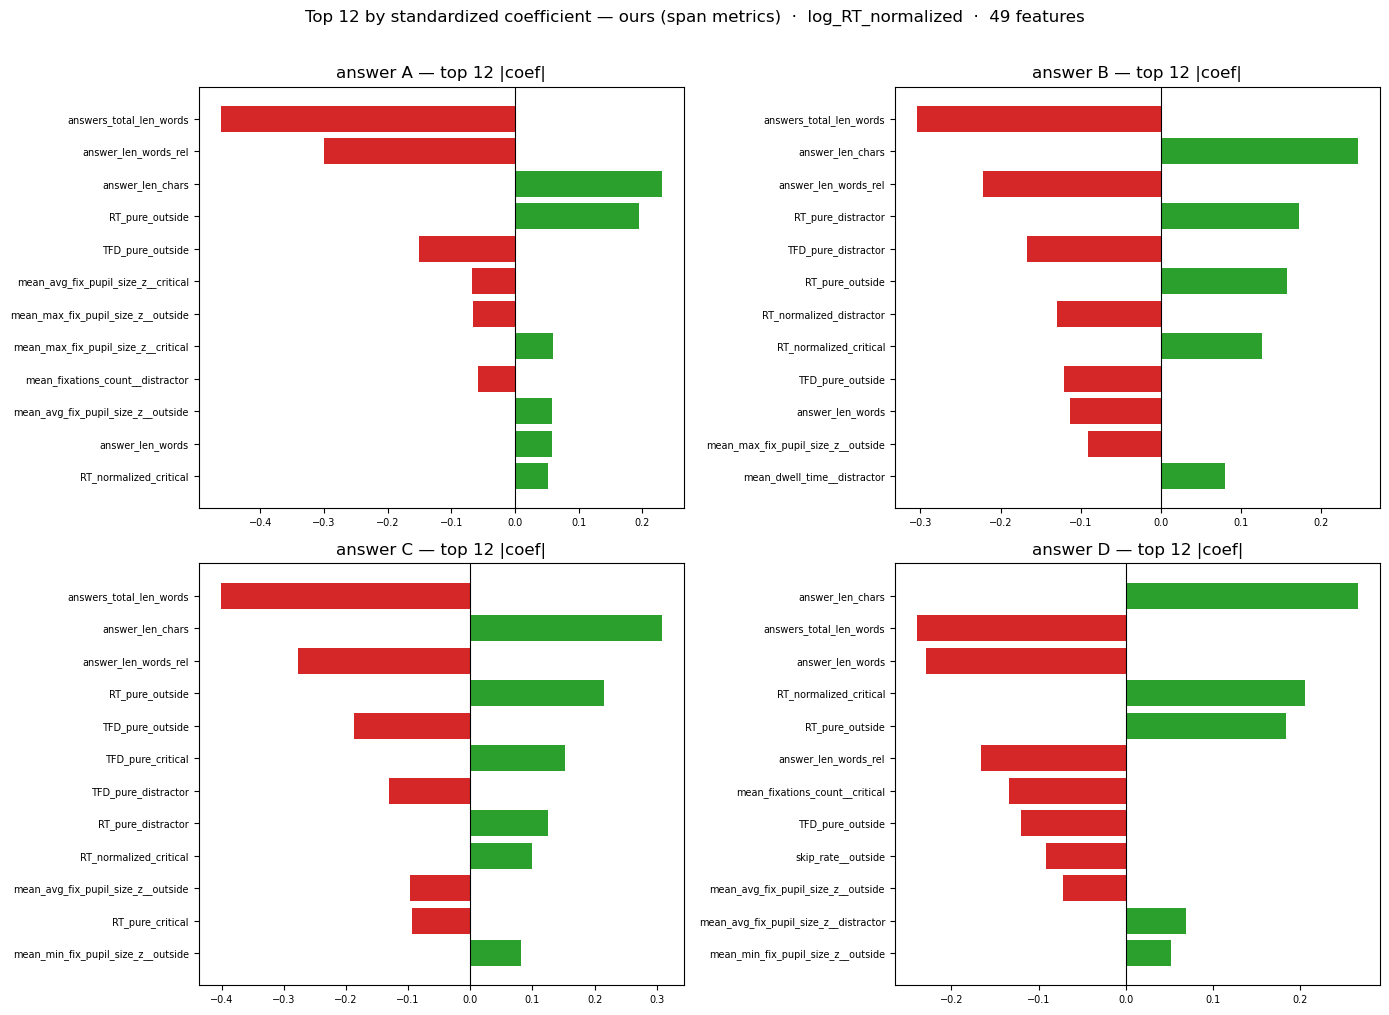

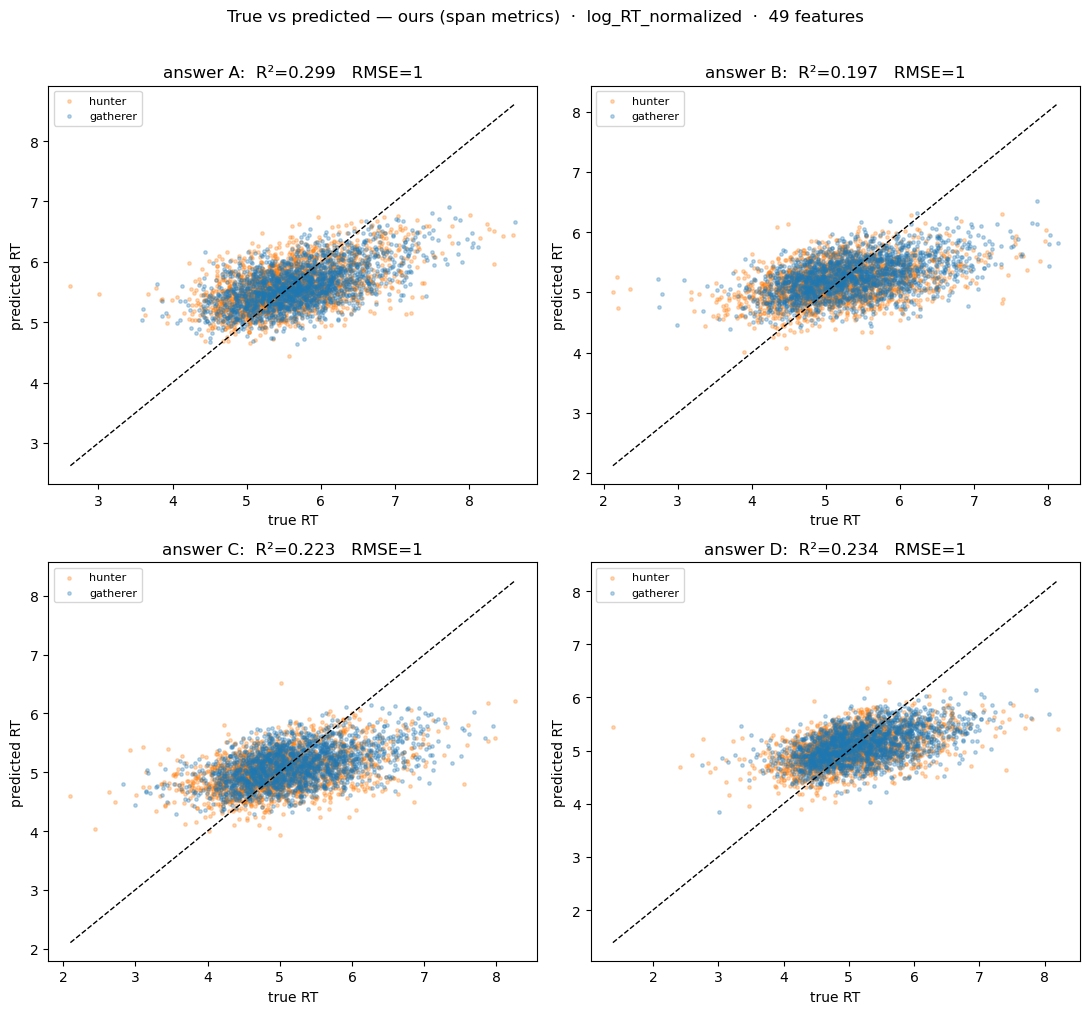

In [6]:
# --- the four target variants: metric x log ---------------------------------
RT_METRIC = "RT_normalized"   # "RT_pure" (raw ms) or "RT_normalized" (per word)
LOG_TARGET = True       # True -> log(RT_METRIC), dropping the RT = 0 trials


def run_both_feature_sets(
    rt_metric,
    log_target,
    model_kind="ridge",
    model_kwargs=None,
    include_answer_text=None,
    verbose=True,
):
    """One regression per answer per feature set, for a single target choice.

    `model_kind` / `model_kwargs` pick the estimator, so the same helper drives
    the linear runs below and the gradient-boosting section at the end.
    `include_answer_text` defaults to the notebook-level INCLUDE_ANSWER_TEXT;
    pass it explicitly to run a with/without-text pair in one cell.
    """
    if include_answer_text is None:
        include_answer_text = INCLUDE_ANSWER_TEXT
    return {
        name: run_answer_rt_regression(
            model_df=df_,
            feature_cols=cols_,
            feature_set=name,
            include_answer_text=include_answer_text,
            rt_metric=rt_metric,
            log_target=log_target,
            model_kind=model_kind,
            model_kwargs=model_kwargs,
            test_size=0.2,
            random_state=42,
            verbose=verbose,
        )
        for name, (df_, cols_) in FEATURE_SETS.items()
    }


target_label = f"log({RT_METRIC})" if LOG_TARGET else RT_METRIC
print(f"target: {target_label}")
out_rt = run_both_feature_sets(RT_METRIC, LOG_TARGET)

# Held-out R2, one column per answer.
rt_metrics = pd.concat([out["metrics"] for out in out_rt.values()], ignore_index=True)
display(rt_metrics.pivot(index="feature_set", columns="answer", values="r2").round(3))

plot_coefs(out_rt["ours (span metrics)"])
plot_true_pred(out_rt["ours (span metrics)"])

In [10]:
# All four targets at once, to compare. Takes ~4x the cell above.
sweep_rows = []
for metric in ("RT_pure", "RT_normalized"):
    for log_target in (False, True):
        label = f"log({metric})" if log_target else metric
        for out in run_both_feature_sets(metric, log_target, verbose=False).values():
            sweep_rows.append(out["metrics"].assign(target_kind=label))

rt_sweep = pd.concat(sweep_rows, ignore_index=True)
rt_sweep_r2 = rt_sweep.pivot_table(
    index=["feature_set", "target_kind"], columns="answer", values="r2"
)
rt_sweep_r2["mean"] = rt_sweep_r2.mean(axis=1)
display(rt_sweep_r2.round(3))

answer                                      A      B      C      D   mean
feature_set         target_kind                                          
external (EyeBench) RT_normalized       0.234  0.128  0.149  0.134  0.161
                    RT_pure             0.160  0.117  0.160  0.132  0.142
                    log(RT_normalized)  0.295  0.200  0.234  0.239  0.242
                    log(RT_pure)        0.247  0.217  0.271  0.256  0.247
ours (span metrics) RT_normalized       0.246  0.141  0.156  0.145  0.172
                    RT_pure             0.167  0.125  0.159  0.141  0.148
                    log(RT_normalized)  0.299  0.197  0.223  0.234  0.238
                    log(RT_pure)        0.255  0.215  0.259  0.253  0.245

## A nonlinear model: gradient-boosted trees

`model_kind="hist_gbm"` swaps the ridge for scikit-learn's
`HistGradientBoostingRegressor`, wrapped in `models/gbm_model.py`. The ridge
answers "is there a linear signal"; this answers "is there a nonlinear one" — it
fits interactions the linear model cannot express, most obviously that hunters
and gatherers may have different RT *functions* rather than just different
intercepts. It also consumes NaN natively, so the `fillna(0)`-before-standardizing
step that turns a missing value into a fake z-score of −(mean/sd) never happens.

There is a real nonlinear signal, and it is not target- or feature-set-specific —
the GBM wins all eight combinations (mean held-out R² over the four answers):

| feature set | target | ridge | hist_gbm | gain |
| --- | --- | --- | --- | --- |
| ours | `RT_normalized` | 0.172 | 0.248 | +0.076 |
| ours | `RT_pure` | 0.148 | 0.176 | +0.028 |
| ours | `log(RT_normalized)` | 0.238 | **0.315** | +0.076 |
| ours | `log(RT_pure)` | 0.246 | 0.300 | +0.055 |
| external | `RT_normalized` | 0.161 | 0.250 | +0.089 |
| external | `RT_pure` | 0.142 | 0.174 | +0.032 |
| external | `log(RT_normalized)` | 0.242 | 0.309 | +0.067 |
| external | `log(RT_pure)` | 0.248 | 0.295 | +0.048 |

Two things change once the model is nonlinear. **`log(RT_normalized)` becomes the
best target**, where under the ridge `log(RT_pure)` was marginally ahead — so the
target choice made in the section above is worth re-reading against this model
rather than carried over. And **the two feature sets stay tied** (0.315 vs 0.309
on the best target, ours fractionally ahead): the ~520 external columns still add
nothing over our ~49, so their earlier advantage was not nonlinearity the ridge
was failing to reach.

Two things the wrapper does by hand, because scikit-learn's defaults would
quietly break the participant grouping this whole notebook relies on:

- **Early stopping** with `early_stopping=True` carves its validation slice out
  at random, so the same reader lands on both sides and the stopping point is
  chosen on leakage. Here the slice is cut by participant, the round count comes
  from the staged loss on it, and the final model refits on the whole training
  split at that count. It settles around 40–90 rounds out of 400, so the search
  is doing real work — the `n_iter` table below reports where each run stopped.
- **Importance** is permutation importance (mean drop in R²) measured on those
  held-out participants, from a model that never saw them. This estimator exposes
  no `feature_importances_` and has no coefficients, so the bars in `plot_coefs`
  are unsigned magnitudes here, not signed effects — the figure title says which.

Computing the importance is the slow part (a refit plus one re-prediction per
feature per repeat), and it scales with the predictor count: seconds on our ~49
columns, minutes on the ~520 external ones. Set
`GBM_KWARGS = {"compute_importance": False}` to skip it when only the scores
matter. `GBM_KWARGS` reaches every other hyperparameter too — `learning_rate`,
`max_leaf_nodes`, `min_samples_leaf`, `l2_regularization`, `max_iter`.


In [7]:
# --- gradient boosting on both feature sets ---------------------------------
GBM_RT_METRIC = "RT_normalized"   # "RT_pure" (raw ms) or "RT_normalized" (per word)
GBM_LOG_TARGET = True            # True -> log(GBM_RT_METRIC), dropping the RT = 0 trials
GBM_KWARGS = None                 # e.g. {"learning_rate": 0.02, "compute_importance": False}
COMPARE_TO_RIDGE = True           # also fit the linear model on the same target


GBM_ANSWER_TEXT = False #INCLUDE_ANSWER_TEXT
GBM_TEXT_CONTROL = True           # False -> headline arm only (halves the runtime)

target_label = f"log({GBM_RT_METRIC})" if GBM_LOG_TARGET else GBM_RT_METRIC
models = ["hist_gbm"] + (["ridge"] if COMPARE_TO_RIDGE else [])
text_flags = [GBM_ANSWER_TEXT] + ([not GBM_ANSWER_TEXT] if GBM_TEXT_CONTROL else [])
print(f"target: {target_label}   models: {models}   answer text: {text_flags}\n")

gbm_runs = {}   # (model_kind, include_answer_text) -> {feature set: result}
for kind in models:
    for with_text in text_flags:
        gbm_runs[(kind, with_text)] = run_both_feature_sets(
            GBM_RT_METRIC,
            GBM_LOG_TARGET,
            model_kind=kind,
            model_kwargs=GBM_KWARGS if kind == "hist_gbm" else None,
            include_answer_text=with_text,
            verbose=False,
        )

# Held-out R2, one row per (model, answer text, feature set).
gbm_comparison = pd.concat(
    [
        out["metrics"].assign(model=kind, answer_text=with_text)
        for (kind, with_text), runs_ in gbm_runs.items()
        for out in runs_.values()
    ],
    ignore_index=True,
).pivot_table(
    index=["model", "answer_text", "feature_set"], columns="answer", values="r2"
)
gbm_comparison["mean"] = gbm_comparison.mean(axis=1)
display(gbm_comparison.round(3))

# What the text features are actually worth, per model and feature set.
if GBM_TEXT_CONTROL:
    by_text = (
        gbm_comparison["mean"]
        .unstack("answer_text")
        .rename(columns={True: "with text", False: "no text"})
    )
    by_text["gain from text"] = by_text["with text"] - by_text["no text"]
    display(by_text.round(3))

# Plots and the stopping curve come from the headline GBM arm only.
headline = gbm_runs[("hist_gbm", GBM_ANSWER_TEXT)]

# Where the participant-grouped early stopping settled, per run.
display(
    pd.concat([out["metrics"] for out in headline.values()], ignore_index=True)
    .pivot_table(index="feature_set", columns="answer", values="n_iter")
    .astype(int)
)

for name, out in headline.items():
    plot_coefs(out)
    plot_true_pred(out)


target: log(RT_normalized)   models: ['hist_gbm', 'ridge']   answer text: [False, True]



KeyboardInterrupt: 

### The same model without the text features

One model, one arm: gradient boosting on the paragraph reading measures alone,
no answer/question sizes, no linear comparison. This is the honest baseline the
text features are incremental over, and it is the number to quote when the claim
is about what *eye movements* predict.

It is also where the GBM's advantage over the ridge goes away: on our set both
land at R² ≈ 0.025 against `RT_normalized`. So the nonlinearity the boosting was
buying is the `1/length` curve, not structure in the reading measures.


target: log(RT_normalized)   model: hist_gbm   answer text: excluded

answer A: R2=0.057 RMSE=0.647 (baseline 0.667) MAE=0.501  [alpha=-, n_feat=43, n_train=15492, n_test=3876]
answer B: R2=0.053 RMSE=0.707 (baseline 0.727) MAE=0.550  [alpha=-, n_feat=43, n_train=15110, n_test=3813]
answer C: R2=0.082 RMSE=0.684 (baseline 0.714) MAE=0.528  [alpha=-, n_feat=43, n_train=15093, n_test=3799]
answer D: R2=0.082 RMSE=0.652 (baseline 0.680) MAE=0.504  [alpha=-, n_feat=43, n_train=15138, n_test=3817]
answer A: R2=0.111 RMSE=0.629 (baseline 0.667) MAE=0.489  [alpha=-, n_feat=516, n_train=15492, n_test=3876]
answer B: R2=0.075 RMSE=0.699 (baseline 0.727) MAE=0.545  [alpha=-, n_feat=516, n_train=15110, n_test=3813]
answer C: R2=0.102 RMSE=0.677 (baseline 0.714) MAE=0.522  [alpha=-, n_feat=516, n_train=15093, n_test=3799]
answer D: R2=0.106 RMSE=0.643 (baseline 0.680) MAE=0.496  [alpha=-, n_feat=516, n_train=15138, n_test=3817]


answer,A,B,C,D,mean
feature_set,,,,,
external (EyeBench),0.111,0.075,0.102,0.106,0.098
ours (span metrics),0.057,0.053,0.082,0.082,0.069


answer,A,B,C,D
feature_set,,,,
external (EyeBench),110,132,87,88
ours (span metrics),59,47,50,69


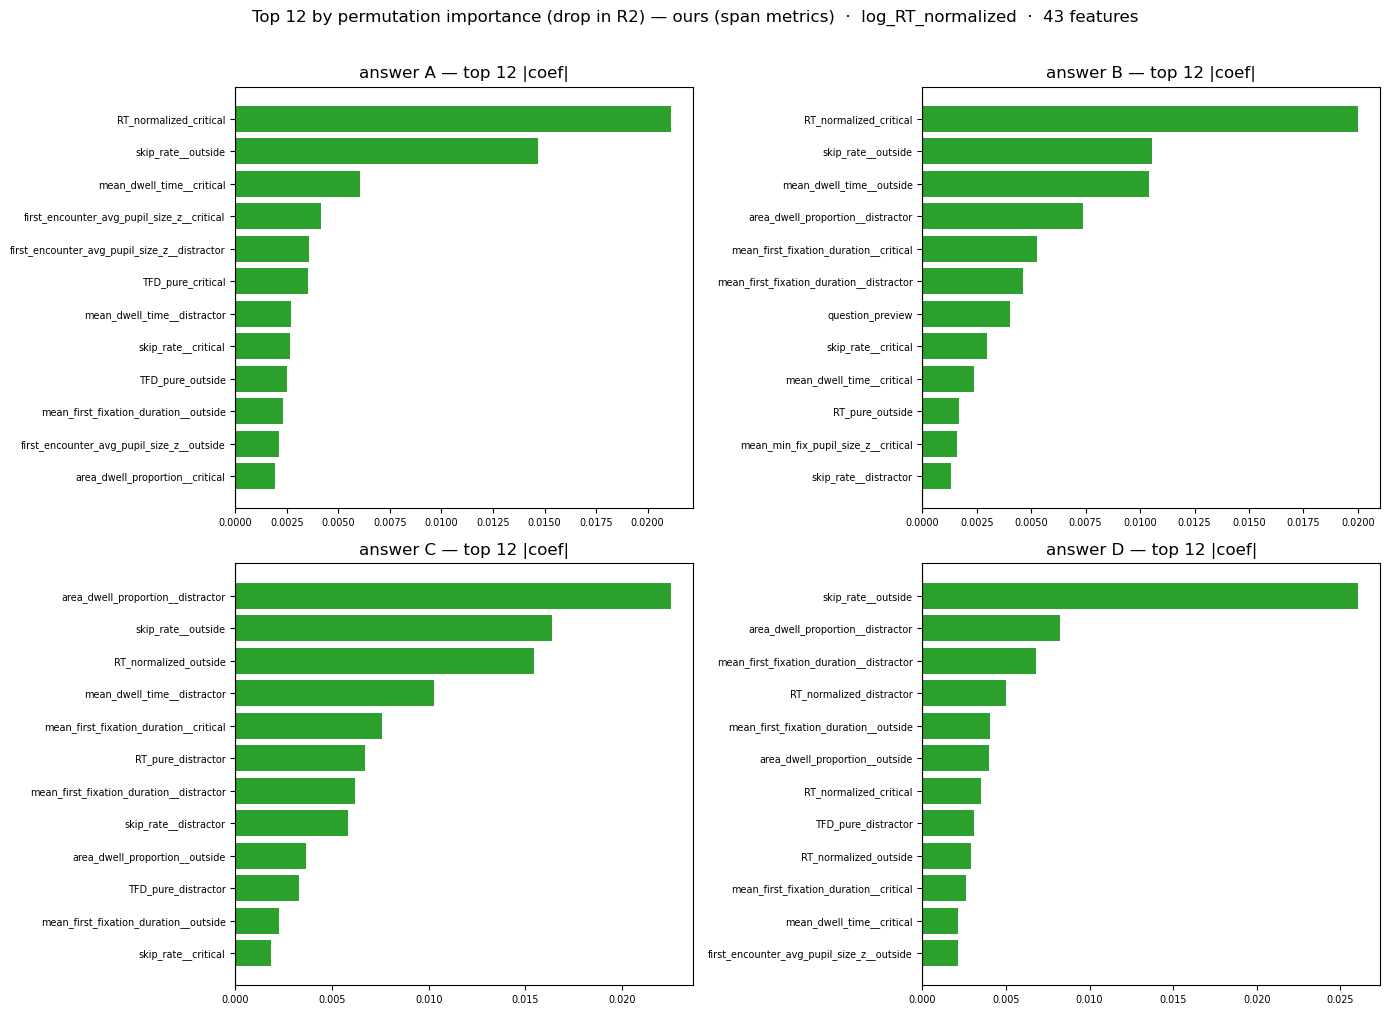

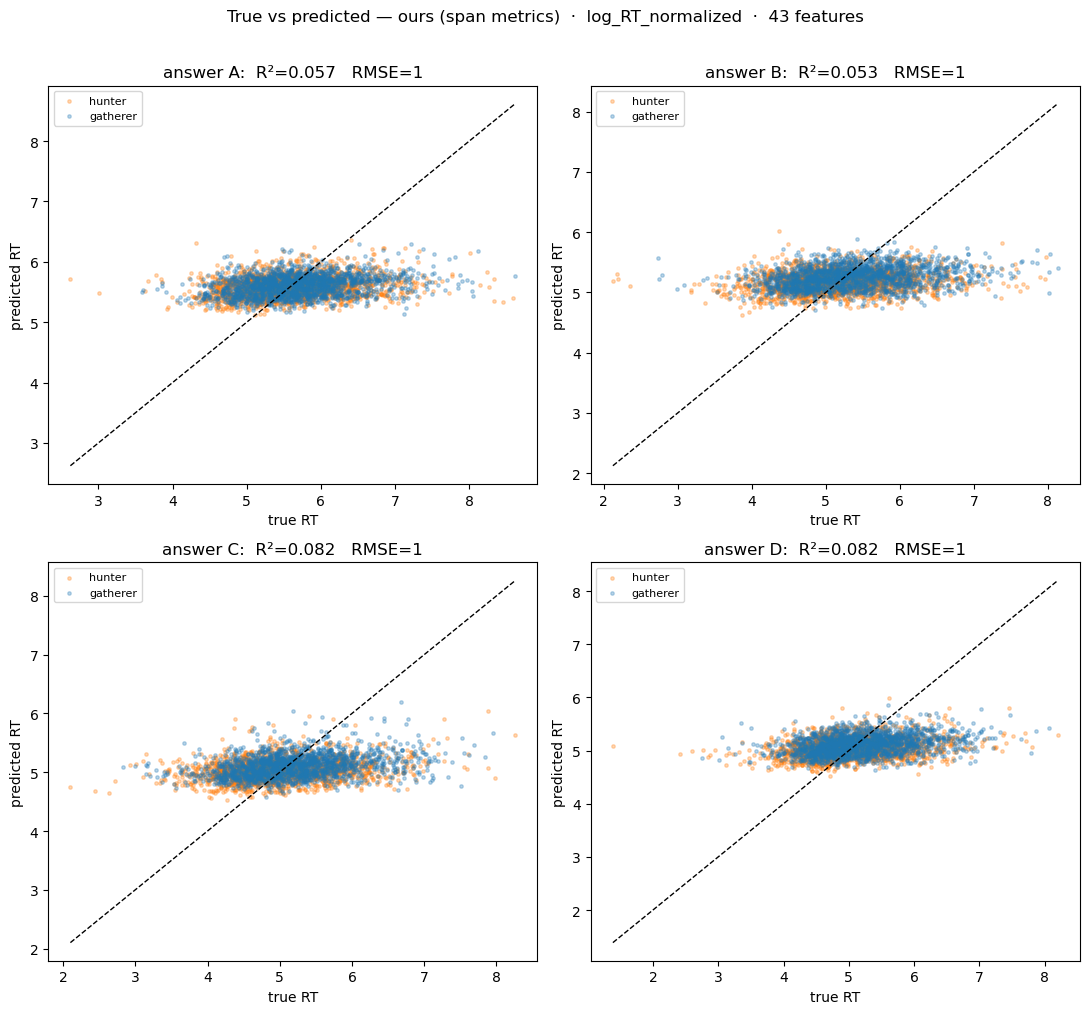

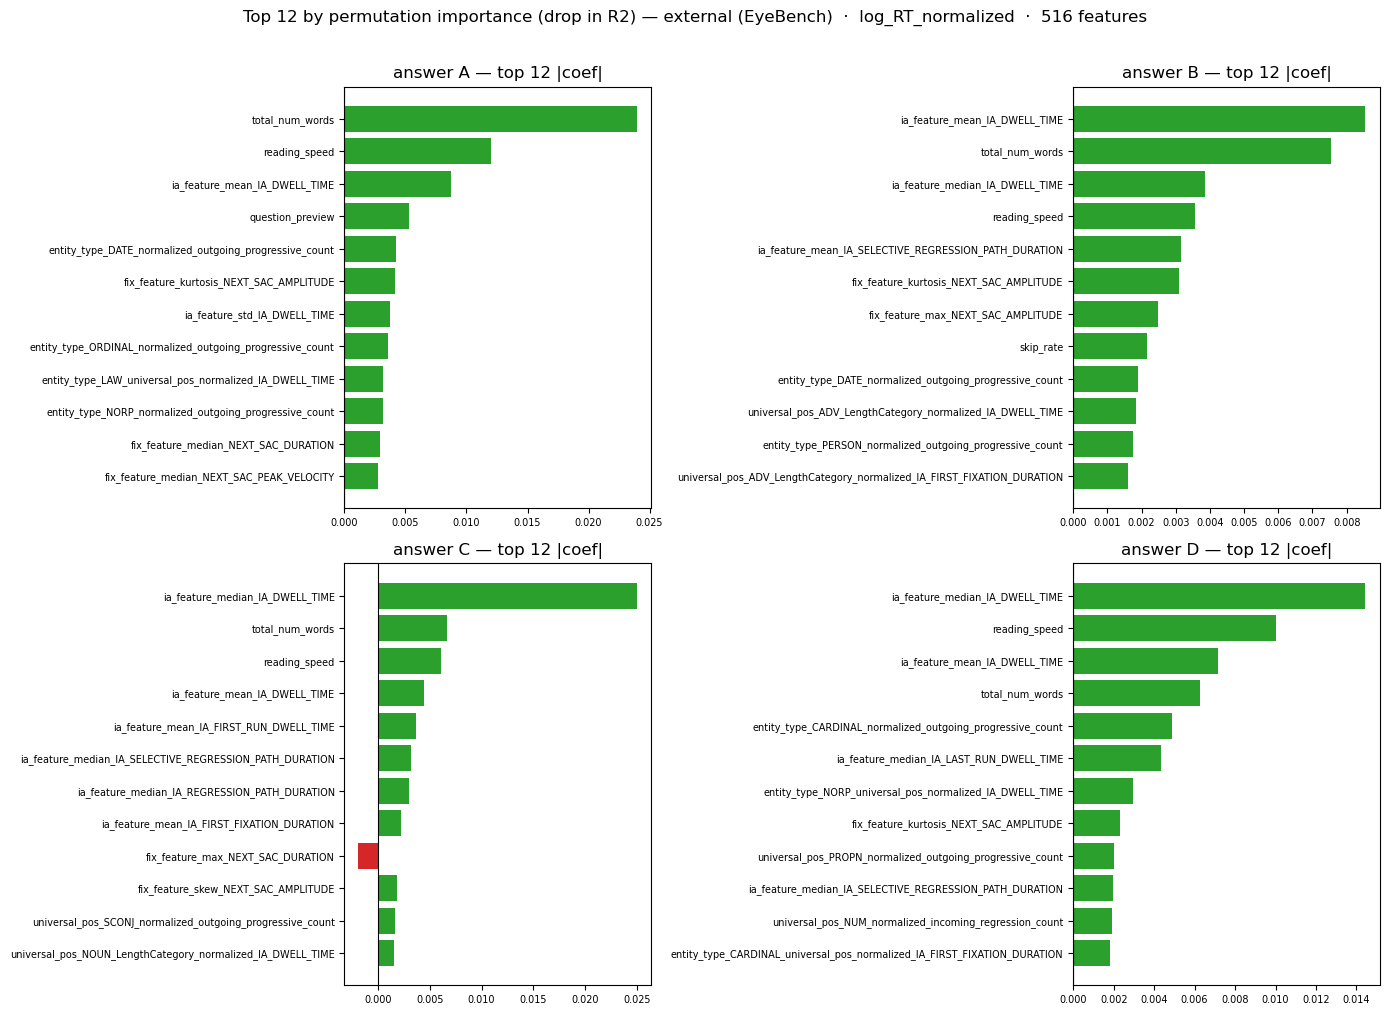

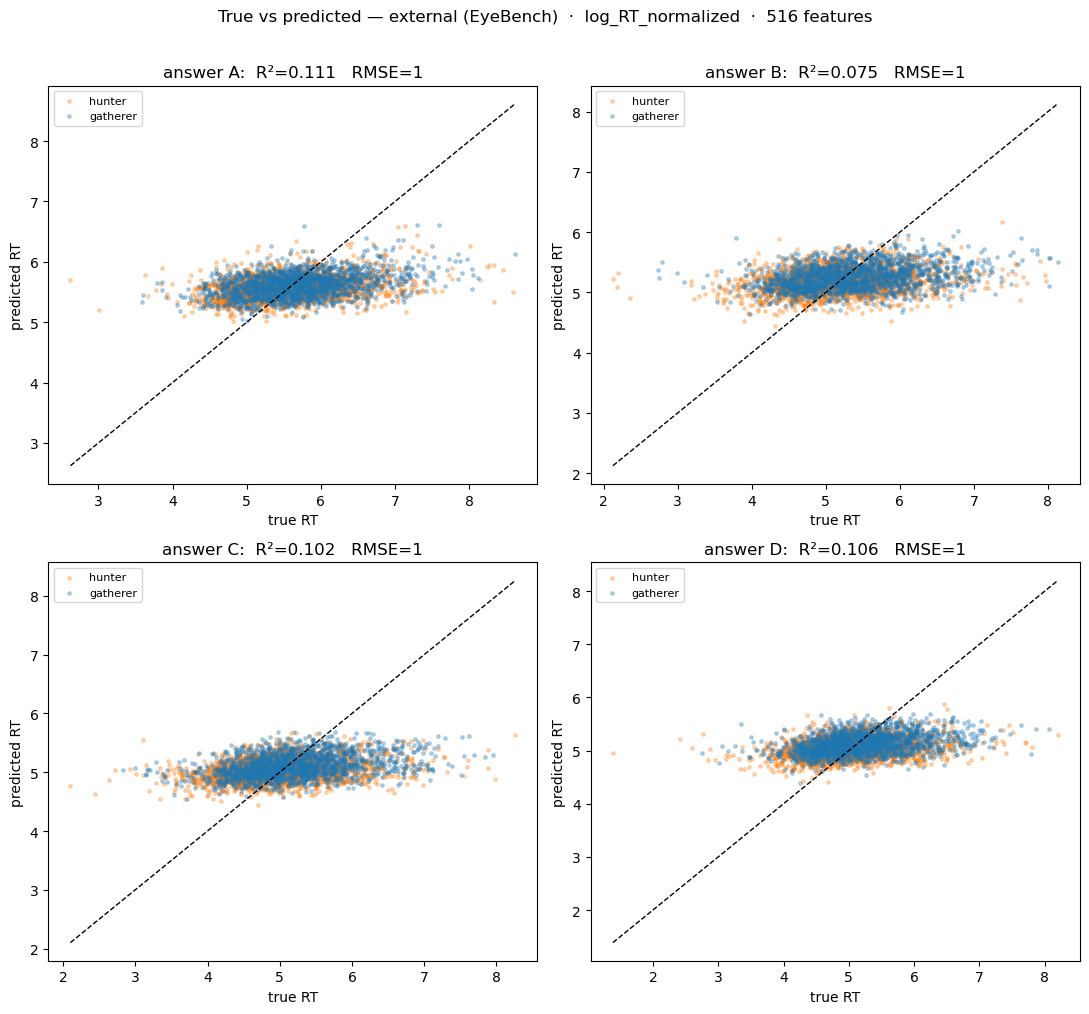

In [8]:
# --- the GBM on the eye-tracking features alone -----------------------------
NOTEXT_RT_METRIC = "RT_normalized"   # "RT_pure" (raw ms) or "RT_normalized" (per word)
NOTEXT_LOG_TARGET = True             # True -> log(NOTEXT_RT_METRIC), dropping the RT = 0 trials
NOTEXT_KWARGS = None                 # e.g. {"learning_rate": 0.02, "compute_importance": False}

notext_label = f"log({NOTEXT_RT_METRIC})" if NOTEXT_LOG_TARGET else NOTEXT_RT_METRIC
print(f"target: {notext_label}   model: hist_gbm   answer text: excluded\n")

out_notext = run_both_feature_sets(
    NOTEXT_RT_METRIC,
    NOTEXT_LOG_TARGET,
    model_kind="hist_gbm",
    model_kwargs=NOTEXT_KWARGS,
    include_answer_text=False,
)

notext_metrics = pd.concat(
    [out["metrics"] for out in out_notext.values()], ignore_index=True
)

# Held-out R2 per answer. The baseline every one of these is measured against is
# a mean predictor, so a near-zero R2 here means the reading measures carry
# essentially nothing once answer length is out of the picture.
notext_r2 = notext_metrics.pivot_table(
    index="feature_set", columns="answer", values="r2"
)
notext_r2["mean"] = notext_r2.mean(axis=1)
display(notext_r2.round(3))

# Where the participant-grouped early stopping settled.
display(
    notext_metrics.pivot_table(
        index="feature_set", columns="answer", values="n_iter"
    ).astype(int)
)

for name, out in out_notext.items():
    plot_coefs(out)
    plot_true_pred(out)
